# Order-sensitivity check: does swapping item 1 / item 2 change PAIR's prediction?

The interaction vector `concat[h1, h2, h1*h2, |h1-h2|]` only has two of its
four blocks (`h1*h2`, `|h1-h2|`) guaranteed invariant to swapping which item
is encoded as "item 1" vs "item 2" -- the raw `concat[h1, h2]` part is not,
since swapping the inputs literally swaps which encoded vector lands in
which slot. Training pairs are also always stored with `Parameter1 <
Parameter2` (alphabetical order; see `data_integration.R`), a fixed
convention the model has only ever seen in one direction, so nothing forces
the network to have learned order-invariant behavior for that part of the
input.

This notebook quantifies how much PAIR's predictions actually change when
an evaluated pair is presented in the reverse order, on the training,
holdout, and validation pair tables. It does not touch accuracy against the
human-rated correlations at all -- it only compares the model against
itself under both orderings of the same pairs.

In [1]:
# --- 1. Imports & config ---
import os
import numpy as np
import polars as pl
import torch
import joblib
import matplotlib.pyplot as plt

from siamese_model import SiameseEncoder, SiameseDNN

emb_model = "tencent-KaLM-Embedding-Gemma3-12B-2511"

train_pair_path = "../../data/raw/item_correlations.parquet"
hold_pair_path  = "../../data/raw/holdout_item_correlations.parquet"
val_pair_path   = "../../data/raw/validation_item_correlations.parquet"

train_emb_path = f"../../data/raw/{emb_model}/embeddings_raw.parquet"
hold_emb_path  = f"../../data/raw/{emb_model}/holdout_embeddings_raw.parquet"
val_emb_path   = f"../../data/raw/{emb_model}/validation_embeddings_raw.parquet"

CKPT_PATH   = f"../../models/{emb_model}/dnn_siamese_cor.pt"
SCALER_PATH = f"../../models/{emb_model}/quantile_transformer.joblib"

ENCODER_DIMS = (384,)
HEAD_DIMS    = (256, 130)
DROPOUT      = 0.226   # inert at eval time either way (model.eval() disables dropout)
USE_SKIP     = False

SAMPLE_N   = 20_000   # cap per split so this runs quickly; set to None to use all pairs
SEED       = 42
EVAL_CHUNK = 8192

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
torch.manual_seed(SEED); np.random.seed(SEED)

Device: cuda:0


In [2]:
# --- 2. Load the combined embedding lookup (train + holdout + validation items) ---
# Mirrors model_validation.ipynb's lookup-building logic so every item across
# all three splits has a slot, regardless of which pair table we're scoring.

def load_emb(path):
    df = pl.read_parquet(path)
    cols = [c for c in df.columns if c.startswith("emb")]
    return df["item"].to_list(), df.select(cols).to_numpy()

train_items, train_emb = load_emb(train_emb_path)
hold_items,  hold_emb  = load_emb(hold_emb_path)
val_items,   val_emb   = load_emb(val_emb_path)

EMB_DIM = train_emb.shape[1]
item_to_idx = {}
emb_rows = []
for names, arr in [(train_items, train_emb), (hold_items, hold_emb), (val_items, val_emb)]:
    for name, row in zip(names, arr):
        if name not in item_to_idx:
            item_to_idx[name] = len(emb_rows)
            emb_rows.append(row)

ITEM_EMB = torch.tensor(np.stack(emb_rows), dtype=torch.float32).to(device)
print(f"Combined item lookup: {ITEM_EMB.shape[0]:,} items, emb_dim={EMB_DIM}")

Combined item lookup: 3,367 items, emb_dim=3840


In [3]:
# --- 3. Load the trained scaler + checkpoint ---
scaler = joblib.load(SCALER_PATH)
AUX_DIM = scaler.n_features_in_

model = SiameseDNN(
    emb_dim=EMB_DIM, aux_dim=AUX_DIM,
    encoder_dims=ENCODER_DIMS, head_dims=HEAD_DIMS,
    dropout=DROPOUT, use_skip=USE_SKIP,
).to(device)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()
print(f"Loaded checkpoint from {CKPT_PATH}")

Loaded checkpoint from ../../models/tencent-KaLM-Embedding-Gemma3-12B-2511/dnn_siamese_cor.pt


## Order-sensitivity test

For a sample of pairs from each split, score the pair as stored
(`item1, item2`) and again with the two items swapped (`item2, item1`),
using the identical `global_sim` (cosine similarity is symmetric, so this
part never differs) and the identical scaler-transformed aux feature. Any
difference between the two predictions is attributable purely to the raw
`concat[h1, h2]` half of the interaction vector.

In [4]:
# --- 4. Helper: score a pair table both ways ---

def add_global_sim(idx1, idx2, emb, chunk=50_000):
    En = torch.nn.functional.normalize(emb, dim=1)
    out = np.empty(len(idx1), dtype=np.float32)
    with torch.no_grad():
        for s in range(0, len(idx1), chunk):
            sl = slice(s, s + chunk)
            a = En[torch.as_tensor(idx1[sl], device=En.device)]
            b = En[torch.as_tensor(idx2[sl], device=En.device)]
            out[sl] = (a * b).sum(dim=1).cpu().numpy()
    return out

def score_batch(idx1_t, idx2_t, aux_t):
    chunks = []
    with torch.no_grad():
        for s in range(0, idx1_t.shape[0], EVAL_CHUNK):
            e1 = ITEM_EMB[idx1_t[s:s+EVAL_CHUNK]]
            e2 = ITEM_EMB[idx2_t[s:s+EVAL_CHUNK]]
            ax_ = aux_t[s:s+EVAL_CHUNK]
            chunks.append(torch.tanh(model(e1, e2, ax_)).cpu().numpy())
    return np.concatenate(chunks)

def order_sensitivity(pair_path, split_name, sample_n=SAMPLE_N, seed=SEED):
    df = pl.read_parquet(pair_path).filter(
        (pl.col("r").is_not_null()) & (pl.col("r") != 1)
    )
    df = df.filter(
        pl.col("Parameter1").is_in(list(item_to_idx.keys())) &
        pl.col("Parameter2").is_in(list(item_to_idx.keys()))
    )
    if sample_n is not None and df.height > sample_n:
        df = df.sample(n=sample_n, seed=seed)

    idx1 = np.fromiter((item_to_idx[p] for p in df["Parameter1"].to_list()), np.int64)
    idx2 = np.fromiter((item_to_idx[p] for p in df["Parameter2"].to_list()), np.int64)

    gsim = add_global_sim(idx1, idx2, ITEM_EMB)   # symmetric -- identical for both orderings
    aux = scaler.transform(gsim.reshape(-1, 1))
    aux_t = torch.tensor(aux, dtype=torch.float32, device=device)

    idx1_t = torch.tensor(idx1, dtype=torch.long, device=device)
    idx2_t = torch.tensor(idx2, dtype=torch.long, device=device)

    pred_orig = score_batch(idx1_t, idx2_t, aux_t)
    pred_swap = score_batch(idx2_t, idx1_t, aux_t)   # items swapped, everything else identical

    diff = pred_orig - pred_swap
    result = {
        "split": split_name,
        "n": len(diff),
        "mean_abs_diff": float(np.abs(diff).mean()),
        "median_abs_diff": float(np.median(np.abs(diff))),
        "max_abs_diff": float(np.abs(diff).max()),
        "rmse_orig_vs_swap": float(np.sqrt(np.mean(diff ** 2))),
        "corr_orig_vs_swap": float(np.corrcoef(pred_orig, pred_swap)[0, 1]),
        "frac_diff_gt_0.01": float((np.abs(diff) > 0.01).mean()),
        "frac_diff_gt_0.05": float((np.abs(diff) > 0.05).mean()),
        "frac_diff_gt_0.10": float((np.abs(diff) > 0.10).mean()),
    }
    return result, pred_orig, pred_swap, diff

In [5]:
# --- 5. Run on training, holdout, and validation pairs ---
results = []
preds = {}

for path, name in [(train_pair_path, "train"), (hold_pair_path, "holdout"), (val_pair_path, "validation")]:
    res, pred_orig, pred_swap, diff = order_sensitivity(path, name)
    results.append(res)
    preds[name] = (pred_orig, pred_swap, diff)
    print(f"\n=== {name} (n={res['n']:,}) ===")
    for k, v in res.items():
        if k not in ("split", "n"):
            print(f"  {k}: {v:.5f}" if isinstance(v, float) else f"  {k}: {v}")


=== train (n=20,000) ===
  mean_abs_diff: 0.00000
  median_abs_diff: 0.00000
  max_abs_diff: 0.00000
  rmse_orig_vs_swap: 0.00000
  corr_orig_vs_swap: 1.00000
  frac_diff_gt_0.01: 0.00000
  frac_diff_gt_0.05: 0.00000
  frac_diff_gt_0.10: 0.00000

=== holdout (n=20,000) ===
  mean_abs_diff: 0.00000
  median_abs_diff: 0.00000
  max_abs_diff: 0.00000
  rmse_orig_vs_swap: 0.00000
  corr_orig_vs_swap: 1.00000
  frac_diff_gt_0.01: 0.00000
  frac_diff_gt_0.05: 0.00000
  frac_diff_gt_0.10: 0.00000

=== validation (n=20,000) ===
  mean_abs_diff: 0.00000
  median_abs_diff: 0.00000
  max_abs_diff: 0.00000
  rmse_orig_vs_swap: 0.00000
  corr_orig_vs_swap: 1.00000
  frac_diff_gt_0.01: 0.00000
  frac_diff_gt_0.05: 0.00000
  frac_diff_gt_0.10: 0.00000


In [6]:
# --- 6. Summary table ---
import pandas as pd
summary = pd.DataFrame(results).set_index("split")
summary

,n,mean_abs_diff,median_abs_diff,max_abs_diff,rmse_orig_vs_swap,corr_orig_vs_swap,frac_diff_gt_0.01,frac_diff_gt_0.05,frac_diff_gt_0.10
split,,,,,,,,,
train,20000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
holdout,20000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
validation,20000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


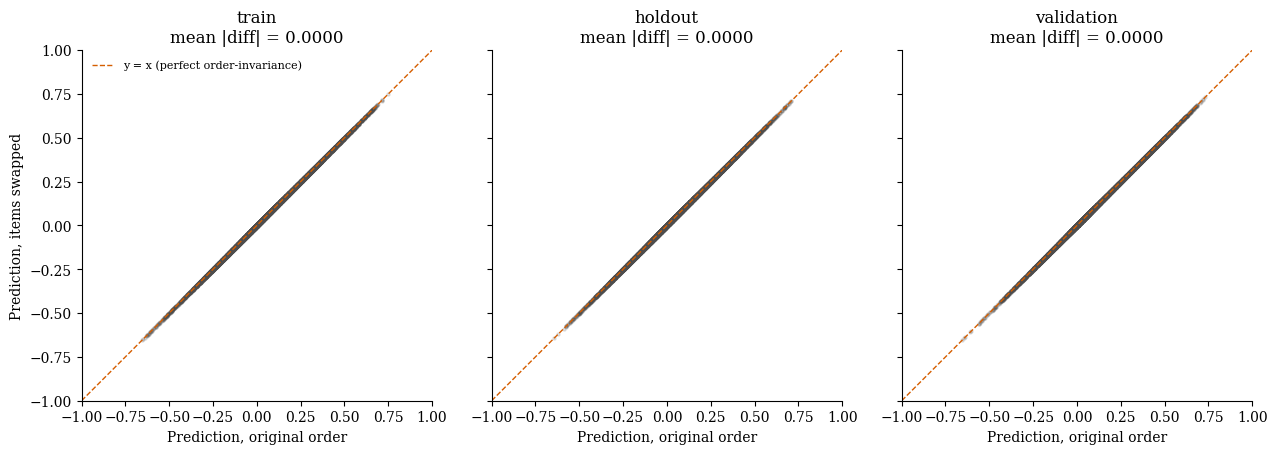

In [7]:
# --- 7. Visualize: predicted (original order) vs predicted (swapped order) ---
plt.rcParams.update({"font.family": "serif", "font.size": 10})

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), sharex=True, sharey=True)
for ax, name in zip(axes, ["train", "holdout", "validation"]):
    pred_orig, pred_swap, diff = preds[name]
    ax.scatter(pred_orig, pred_swap, alpha=0.15, s=5, color="#4D4D4D", rasterized=True)
    ax.plot([-1, 1], [-1, 1], color="#D55E00", lw=1, ls="--", label="y = x (perfect order-invariance)")
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{name}\nmean |diff| = {np.abs(diff).mean():.4f}")
    ax.set_xlabel("Prediction, original order")
    if name == "train":
        ax.set_ylabel("Prediction, items swapped")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(loc="upper left", fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig("../../order_sensitivity_check.pdf", bbox_inches="tight")
plt.savefig("../../order_sensitivity_check.png", dpi=300, bbox_inches="tight")
plt.show()

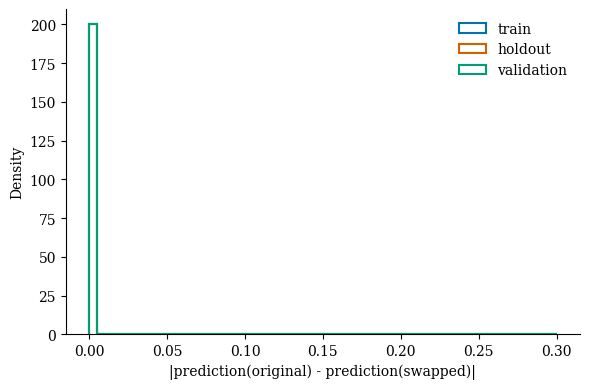

In [8]:
# --- 8. Distribution of |prediction difference| per split ---
fig, ax = plt.subplots(figsize=(6, 4))
for name, color in zip(["train", "holdout", "validation"], ["#0072B2", "#D55E00", "#009E73"]):
    _, _, diff = preds[name]
    ax.hist(np.abs(diff), bins=60, range=(0, max(0.3, np.abs(diff).max())),
            histtype="step", lw=1.5, label=name, color=color, density=True)
ax.set_xlabel("|prediction(original) - prediction(swapped)|")
ax.set_ylabel("Density")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Reading the results

If PAIR were fully order-invariant, every point in the scatter plots above
would sit exactly on the `y = x` line and every `mean_abs_diff` /
`rmse_orig_vs_swap` value in the summary table would be ~0. The degree of
scatter away from that line, and the `frac_diff_gt_*` rows, quantify how
much the raw `concat[h1, h2]` half of the interaction vector is actually
mattering in practice versus how much the symmetric `h1*h2` / `|h1-h2|`
terms are dominating.

Depending on what these numbers look like:

- **If differences are small and rare** (e.g., `mean_abs_diff` well under
  the model's own RMSE against human ratings, `frac_diff_gt_0.05` near
  zero): the raw-concat asymmetry exists in principle but the network
  appears to have converged to an approximately symmetric function in
  practice. Worth stating in the paper as a checked, quantified
  reassurance rather than an unverified architectural claim.
- **If differences are non-trivial**: this is a real robustness issue
  worth fixing before publication -- either by switching to fully
  symmetric interaction terms (dropping the raw `concat[h1, h2]`), by
  order-augmenting the training pairs, or by symmetrizing predictions at
  inference time (average the model's output under both orderings).